# SolverV8 example: multi-pathway 2Q spectrum

Notebook version of `chi7_multiorder_plot_example.py`.

The current configuration uses five interactions (`--+++`), so it computes the chi5-style 2Q example even though the original script name contains chi7.


In [35]:
from pathlib import Path

import numpy as np

from SolverV9 import (
    LiouvilleSpectroscopySolver,
    SpectroscopyPlotter,
    standard_nq_protocol,
)


### Coupled Two-Mode Model

This model describes two local transitions, labeled **h** and **l**, coupled through an excitonic interaction.

- `omega_h`, `omega_l`: Local transition energies in eV.
- `J`: Coupling between the two modes. It mixes the local states and produces delocalized eigenstates.
- `mu_h`, `mu_l`: Transition dipole amplitudes. Their squares approximately determine the relative oscillator strengths.
- `kappa`: Relaxation or dissipation rate included in the dynamics.
- `U_hh`, `U_ll`: Anharmonicities associated with two excitations occupying mode **h** or **l**, respectively.
- `U_hl`: Cross-interaction between one excitation on mode **h** and one on mode **l**.
- `max_manifold`: Maximum number of excitations included in the Hilbert space. A value of `3` includes up to the triply excited manifold.

Here, the negative anharmonicities `U_hh = U_ll = -0.020 eV` lower the energies of double excitations on the same mode, while `U_hl = 0.030 eV` raises the energy of states containing excitations on both modes.

### Solver Parameters

- `T`: System temperature. `T = 0` assumes that the system initially occupies its ground state.
- `Eta`: Homogeneous broadening used in the resolvents, in eV. It primarily controls the spectral linewidth.
- `backend`: Numerical implementation used by the solver. `"dense"` uses dense matrices and NumPy linear-algebra routines.

In [36]:
model_params = {
    "omega_h": 1.53,
    "omega_l": 1.58,
    "J": 0.010,
    "mu_h": 1.0,
    "mu_l": 0.3,
    "kappa": 0.001,
    "U_hh": -0.020,
    "U_ll": -0.020,
    "U_hl": 0.03,
    "max_manifold": 3,
}

solver_params = {
    "T": 0.0,
    "Eta": 0.005,
    "backend": "dense",
}


In [37]:
def build_bosonic_triexciton_model(params):
    maximum_manifold = int(params["max_manifold"])
    basis = tuple(
        (n_h, total - n_h)
        for total in range(maximum_manifold + 1)
        for n_h in range(total, -1, -1)
    )
    index = {state: i for i, state in enumerate(basis)}

    b_h = np.zeros((len(basis), len(basis)), dtype=complex)
    b_l = np.zeros_like(b_h)
    for upper_index, (n_h_value, n_l_value) in enumerate(basis):
        if n_h_value:
            b_h[index[(n_h_value - 1, n_l_value)], upper_index] = np.sqrt(
                n_h_value
            )
        if n_l_value:
            b_l[index[(n_h_value, n_l_value - 1)], upper_index] = np.sqrt(
                n_l_value
            )

    n_h = b_h.conj().T @ b_h
    n_l = b_l.conj().T @ b_l
    identity = np.eye(len(basis))
    H = (
        params["omega_h"] * n_h
        + params["omega_l"] * n_l
        + params["J"] * (b_h.conj().T @ b_l + b_l.conj().T @ b_h)
        + 0.5 * params["U_hh"] * n_h @ (n_h - identity)
        + 0.5 * params["U_ll"] * n_l @ (n_l - identity)
        + params["U_hl"] * n_h @ n_l
    )
    mu = (
        params["mu_h"] * (b_h + b_h.conj().T)
        + params["mu_l"] * (b_l + b_l.conj().T)
    )
    c_ops = [(b_h, params["kappa"]), (b_l, params["kappa"])]
    rho0 = np.zeros_like(H)
    rho0[0, 0] = 1.0
    return H, mu, c_ops, rho0, basis


In [38]:
H, mu, c_ops, rho0, basis = build_bosonic_triexciton_model(model_params)
solver = LiouvilleSpectroscopySolver(solver_params)
solver.feed_model(
    H,
    mu,
    c_ops_raw=c_ops,
    initial_density_matrix=rho0,
    density_matrix_basis="site",
)



print("Basis size:", len(basis))


--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
Basis size: 10


### Example: Fifth-Order Double-Quantum Signal

This example generates the Liouville pathways contributing to a fifth-order (`χ⁽⁵⁾`) double-quantum (`2Q`) signal.

#### Pathway generation

- `"--+++"`: Phase-matching signature of the five field interactions. The first two interactions use the negative-frequency field component, while the last three use the positive-frequency component.
- `maximum_manifold=2`: Pathways may access states containing at most two excitations. This allows the doubly excited manifold required for a `2Q` coherence.
- `component="chi5_2q"`: Label assigned to this fifth-order double-quantum contribution.

#### Spectroscopy protocol

- `n_interactions=5`: Five light-matter interactions are applied, corresponding to a `χ⁽⁵⁾` response.
- `order=2`: Only pathways containing a second-order coherence, `|q| = 2`, are selected.
- `nq_interval=2`: The `2Q` coherence is required during the second evolution interval, after the second interaction. This interval is Fourier transformed along `omega_2q`.
- `detection_interval=5`: The emitted coherence is evaluated after the fifth and final interaction. This interval is Fourier transformed along `omega_emit`.
- `nq_axis="omega_2q"`: Name of the double-quantum frequency axis.
- `detection_axis="omega_emit"`: Name of the emission-frequency axis.


In [39]:
pathways = solver.generate_pathways_with_ufss(
    "--+++",
    maximum_manifold=2,
    component="chi5_2q",
)

protocol = standard_nq_protocol(
    order=2,
    nq_interval=2,
    detection_interval=5,
    n_interactions=5,
    nq_axis="omega_2q",
    detection_axis="omega_emit",
)

[(pathway.name, pathway.interactions, pathway.coherence_orders) for pathway in pathways]


[('P1', ('Bu', 'Bu', 'Ku', 'Ku', 'Bd'), (-1, -2, -1, 0, 1)),
 ('P2', ('Bu', 'Bu', 'Ku', 'Bd', 'Ku'), (-1, -2, -1, 0, 1)),
 ('P3', ('Bu', 'Bu', 'Ku', 'Bd', 'Bd'), (-1, -2, -1, 0, 1)),
 ('P4', ('Bu', 'Bu', 'Bd', 'Ku', 'Ku'), (-1, -2, -1, 0, 1)),
 ('P5', ('Bu', 'Bu', 'Bd', 'Ku', 'Bd'), (-1, -2, -1, 0, 1)),
 ('P6', ('Bu', 'Bu', 'Bd', 'Bd', 'Ku'), (-1, -2, -1, 0, 1))]

In [40]:
omega_2q = np.linspace(-3.20,-2.80, 100)
omega_emit = np.linspace(1.38, 1.68, 100)

delays = {
    "t1": 3.0,
    "t3": 3.0,
    "t4": 3.0

}

result = solver.generate_NQ_spectrum(
    2,
    protocol,
    axes={"omega_2q": omega_2q, "omega_emit": omega_emit},
    delays=delays,
    pathways=pathways,
)


Calculating 6 pathway spectrum/s on a 100x100 grid with protocol 'standard_2q' using parallel=serial, n_jobs=1.
Using dense prefix-tree pathway reuse.


### Plotting Parameters

This block plots the individual `χ⁽⁵⁾` double-quantum pathways and their summed `2Q` signal.

- `save_pdf=True`: Saves the resulting figure as a PDF.
- `output_directory`: Directory where the PDF is written.
- `detection_phase=0`: Applies no additional phase rotation to the complex signal before selecting the displayed component.
- `result`: Spectrum result returned by `solver.generate_NQ_spectrum(...)`.
- `pathways="all"`: Plots every individual pathway stored in `result`.
- `totals=["2Q"]`: Adds a panel containing the sum of the selected `2Q` pathways.
- `view="real"`: Displays the real part of each complex spectrum.
- `normalization="individual"`: Normalizes every pathway and total panel independently. This emphasizes spectral shapes but removes relative amplitude information between panels.
- `axis_labels`: Defines custom labels for the double-quantum and emission-frequency axes.
- `include_diagrams=False`: Does not add double-sided Feynman diagrams to the saved figure.
- `display_diagrams=False`: Does not display the diagrams separately.
- `save_pdf=save_pdf`: Enables or disables PDF export according to the value of `save_pdf`.
- `output_directory=...`: Uses the selected output directory when saving is enabled.
- `spectrum_pdf_name`: Filename used for the exported spectrum.
- `show=True`: Displays the figure after it is generated.

The returned `plot_result` object contains the generated figure and related plotting information.

> **Important:** With `normalization="individual"`, two pathways with very different amplitudes may appear equally intense. Use a common or global normalization when relative pathway strengths must be compared. The user can also use ''none'' to dont normalized, or ''shared'' to normalized all the spectrum togheter. ''individual'' do a individual normalization of each spectrum.

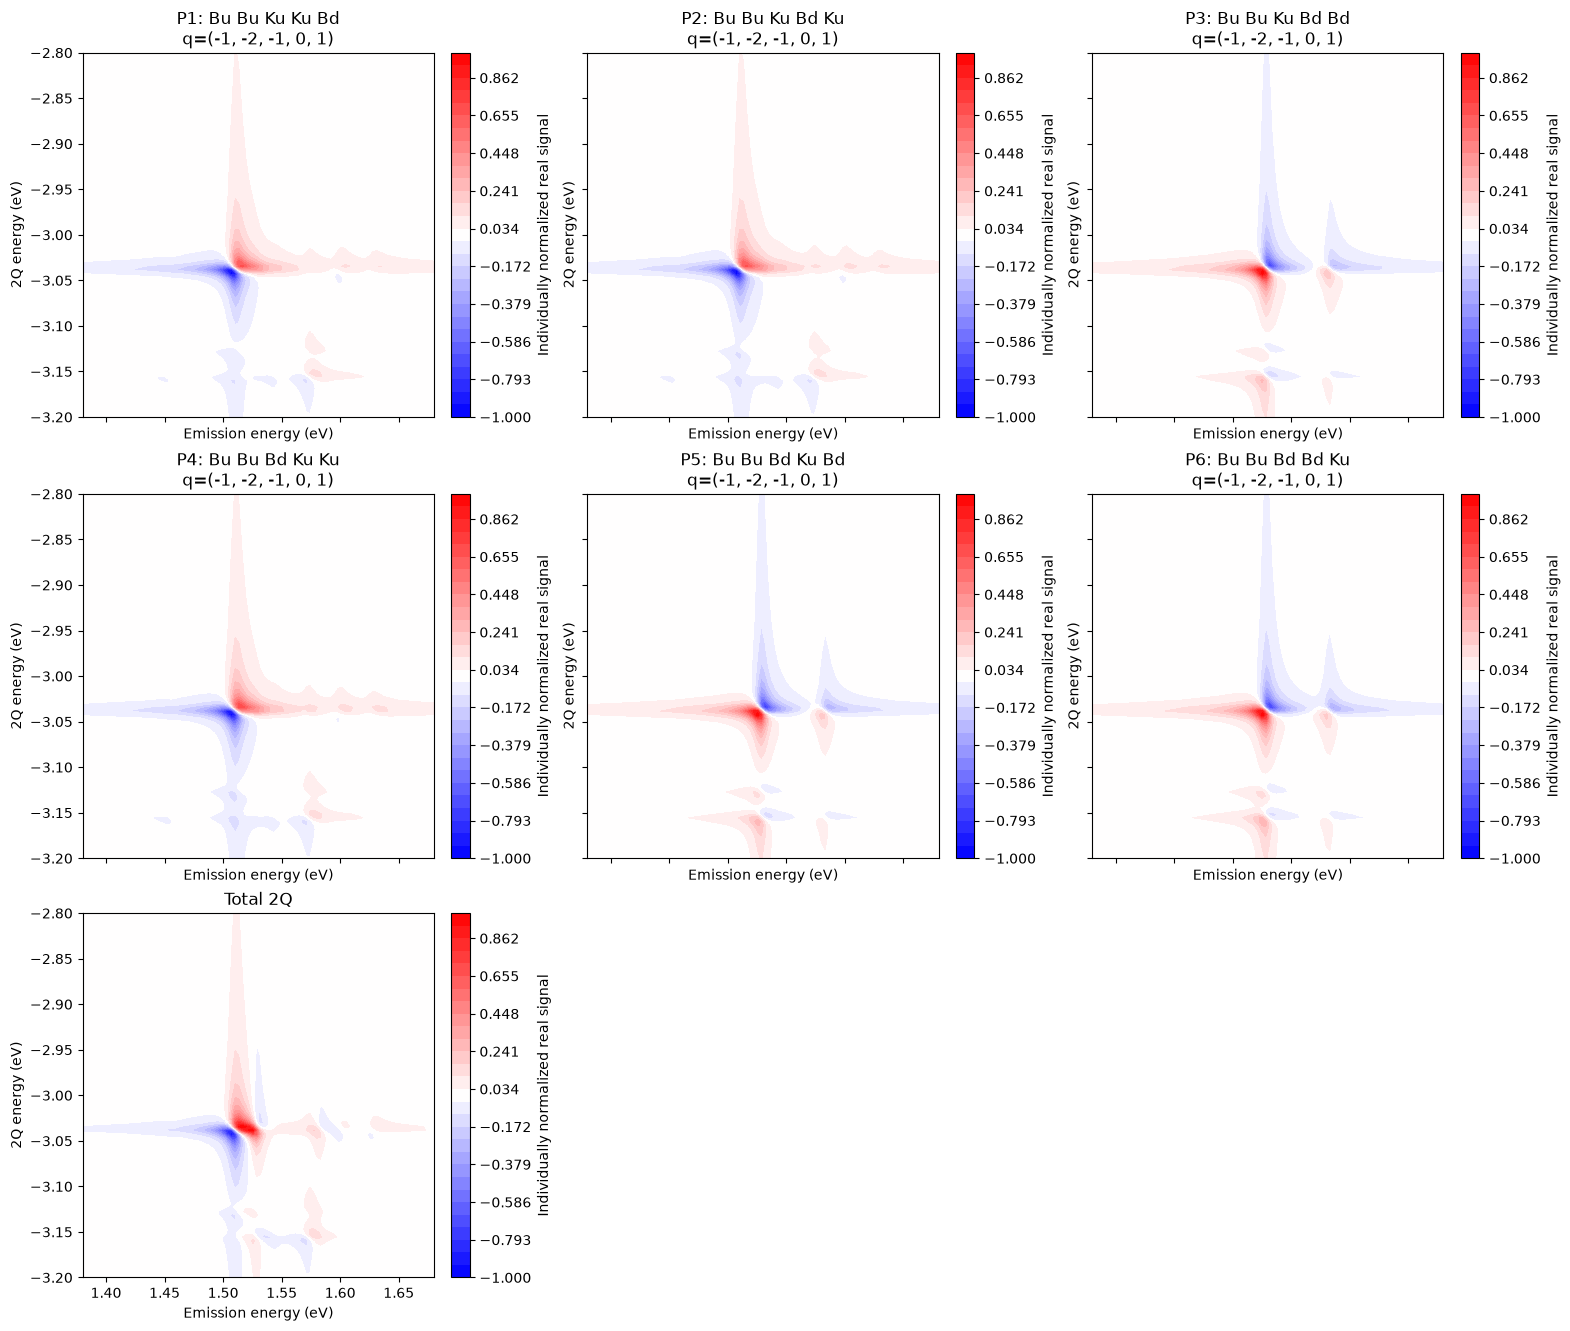

In [41]:
save_pdf = True
output_directory = Path.cwd() / "Result_Test" / "Multiorder_pathway_plot"

plotter = SpectroscopyPlotter(detection_phase=0)
plot_result = plotter.plot_pathways_multiorder(
    result,
    pathways="all",
    totals=["2Q"],
    view="real",
    normalization="individual",
    axis_labels={
        "omega_2q": "2Q energy (eV)",
        "omega_emit": "Emission energy (eV)",
    },
    include_diagrams=False,
    display_diagrams=False,
    save_pdf=save_pdf,
    output_directory=output_directory if save_pdf else None,
    spectrum_pdf_name="chi5_Q2_pathways_ULL_m0_02_UHH_m0_02_UHL_0_03.pdf",
    show=True,
)


In [42]:
print("Plotted panels:", plot_result.panel_names)
print("Matching UFSS diagrams:", tuple(plot_result.diagrams))
if save_pdf:
    print("Spectrum PDF:", plot_result.spectrum_pdf)
    print("Diagram PDFs:", plot_result.diagram_paths)


Plotted panels: ('P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'Total 2Q')
Matching UFSS diagrams: ()
Spectrum PDF: c:\Users\falve\OneDrive\Documents\GitHub\LiouvilleSolver\Result_Test\Multiorder_pathway_plot\chi5_Q2_pathways_ULL_m0_02_UHH_m0_02_UHL_0_03.pdf
Diagram PDFs: {}
